In [1]:
# ipca_pipeline.py (or paste into a notebook cell)

from __future__ import annotations
import os
import contextlib
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
from ipca import InstrumentedPCA

def run_pipeline(
    start_yyyymm: str = "199001",
    end_yyyymm: str = "202412",
    max_nan_frac: float = 0.6,
    cutoff: str = "2015-12-31",
    n_factors: int = 3,
) -> Dict[str, Any]:
    df_raw = download_openap_data(start_yyyymm, end_yyyymm)
    df_keep, dropped = remove_mostly_nan_columns(df_raw, max_nan_frac=max_nan_frac)
    df_filled = fill_remaining_missing(df_keep)

    panel = build_ipca_panel(df_filled, ret_col="excess_ret", shift_target=True)
    train_df, test_df = split_train_test_by_date(panel.df, cutoff=cutoff)

    X_train = train_df[panel.char_cols].to_numpy(np.float64)
    y_train = train_df["y_ipca"].to_numpy(np.float64)
    idx_train = train_df[["i_idx", "t_idx"]].to_numpy(np.int64)

    X_test = test_df[panel.char_cols].to_numpy(np.float64)
    y_test = test_df["y_ipca"].to_numpy(np.float64)
    idx_test = test_df[["i_idx", "t_idx"]].to_numpy(np.int64)

    mod = fit_ipca(X_train, y_train, idx_train, n_factors=n_factors, silent=True)
    r2_train = score_ipca(mod, X_train, y_train, idx_train, mean_factor=False)
    r2_test = score_ipca(mod, X_test, y_test, idx_test, mean_factor=True)  # unseen dates

    return {
        "model": mod,
        "dropped_cols": dropped,
        "char_cols": panel.char_cols,
        "r2_train": r2_train,
        "r2_test_mean_factor": r2_test,
        "train_shape": X_train.shape,
        "test_shape": X_test.shape,
    }


In [86]:
%cd /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master
import sys, importlib
import importlib
import src.ipca_workflow as IPCAWorkflow
importlib.reload(IPCAWorkflow)
importlib.reload(ipca)

/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master


<module 'ipca' from '/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/__init__.py'>

In [4]:
out_path = "/Users/apple/Desktop/Academics/char_data.parquet"
char_data = pd.read_parquet(out_path, engine="pyarrow")

In [5]:
from src.data_pipeline import DataPipeline

new_mod = DataPipeline()  # or keep your existing instance if already created

char_data, dropped_cols = new_mod.remove_mostly_nan_columns(char_data, max_nan_frac=0.5)
print(f"Dropped columns: {dropped_cols}")

returns_data = new_mod.download_sp500_returns_wrds(
    start_date="1990-01-01",
    end_date="2026-01-31",
)

Dropped columns: ['AOP', 'AbnormalAccruals', 'AccrualsBM', 'Activism1', 'Activism2', 'AdExp', 'AgeIPO', 'AnalystRevision', 'AnalystValue', 'BetaTailRisk', 'BrandInvest', 'CBOperProf', 'CPVolSpread', 'Cash', 'ChAssetTurnover', 'ChForecastAccrual', 'ChInvIA', 'ChNAnalyst', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'CustomerMomentum', 'DelBreadth', 'DelDRC', 'DivSeason', 'DivYieldST', 'DownRecomm', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'ExclExp', 'FEPS', 'FR', 'FirmAgeMom', 'ForecastDispersion', 'Frontier', 'Governance', 'GrAdExp', 'GrSaleToGrInv', 'GrSaleToGrOverhead', 'HerfAsset', 'HerfBE', 'IO_ShortInterest', 'IndRetBig', 'IntanBM', 'IntanCFP', 'IntanEP', 'IntanSP', 'InvGrowth', 'Investment', 'MS', 'MeanRankRevGrowth', 'Mom6mJunk', 'MomOffSeason06YrPlus', 'MomOffSeason11YrPlus', 'MomOffSeason16YrPlus', 'MomRev', 'MomSeason06YrPlus', 'MomSeason11YrPlus',

In [6]:
char_data, kept_chars, dropped_chars = new_mod.drop_low_std_and_high_corr(
    char_data,
    min_std=1e-5,   # tune as needed
    max_corr=0.75,  # tune as needed
)

/usr/local/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [7]:
char_data = new_mod.fill_remaining_missing(char_data)

/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local

In [8]:
char_data_copy = char_data.copy()
char_data.head()

,permno,yyyymm,AM,AnnouncementReturn,AssetGrowth,BMdec,Beta,BetaFP,BetaLiquidityPS,BidAskSpread,...,ShareRepurchase,Spinoff,Tax,VolSD,VolumeTrend,betaVIX,hire,Price,Size,STreversal
0,10000,1986-01-01,1.354349,-0.005048,-0.079363,0.812997,0.939402,0.950803,-0.003676,0.010201,...,0.0,0.0,0.605906,-0.132456,-0.007507,-0.005223,-0.003373,-1.475906,-2.778819,-0.000000
1,10000,1986-02-01,1.288478,-0.006319,-0.078568,0.810572,0.943105,0.946533,-0.002954,0.009883,...,0.0,0.0,0.607135,-0.135303,-0.008091,-0.003476,-0.002513,-1.178655,-2.481568,0.257143
2,10000,1986-03-01,1.241767,-0.005388,-0.077011,0.810708,0.940686,0.945886,-0.003437,0.009717,...,0.0,0.0,0.629491,-0.139121,-0.009545,-0.002722,-0.001701,-1.490091,-2.793004,-0.365385
3,10000,1986-04-01,1.235495,-0.004667,-0.076508,0.810708,0.941277,0.885681,0.001821,0.009709,...,0.0,0.0,0.628357,-0.142124,-0.010400,0.000880,-0.000655,-1.386294,-2.719452,0.098592
4,10000,1986-05-01,1.190630,-0.001813,-0.076775,0.805317,0.940010,0.875988,-0.000560,0.009856,...,0.0,0.0,0.628310,-0.140521,-0.010711,0.008871,-0.001751,-1.134423,-2.467581,0.222656


In [9]:
returns_data = returns_data.rename(columns={"excess_ret": "ret_adj"})
char_data = new_mod.merge_openap_with_crsp_returns(char_data, returns_data)

In [8]:
import sys, importlib
from pathlib import Path

ROOT = Path("/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Clear cached mixed imports
for name in list(sys.modules):
    if name == "ipca" or name.startswith("ipca."):
        del sys.modules[name]

import ipca
import ipca.ipca as ipca_mod

print("ipca package:", ipca.__file__)
print("ipca module :", ipca_mod.__file__)

from ipca import InstrumentedPCA


ipca package: /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/__init__.py
ipca module : /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/ipca.py


In [36]:
import importlib
import src.ipca_workflow as ipw
importlib.reload(ipw)
import ipca as ipca
importlib.reload(ipca)
wf = ipw.IPCAWorkflow()
k = 5
pred_df_in, diag_df_in = wf.rolling_ipca_predictions(
    char_data=char_data,
    forecast_start="2020-01-01",
    target_col="y_ipca",
    n_factors=k,              # use k here
    train_window_months=36,
    min_train_obs=500,
    normalize=True,
    mean_factor=True,
    silent=True,
    max_iter=15,
    iter_tol=1e-3,
    warm_start=True,
    use_rff=False,
)

Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=False, warm_Factors=False
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA w

In [38]:
# Overall OOS R²
ss_res = ((pred_df_in["y_true"] - pred_df_in["y_pred"]) ** 2).sum()
ss_tot = (pred_df_in["y_true"] ** 2).sum()  # demeaned vs zero (standard in asset pricing)
r2_oos = 1 - ss_res / ss_tot
print(f"OOS R²: {r2_oos:.4f}")

OOS R²: -9.1698


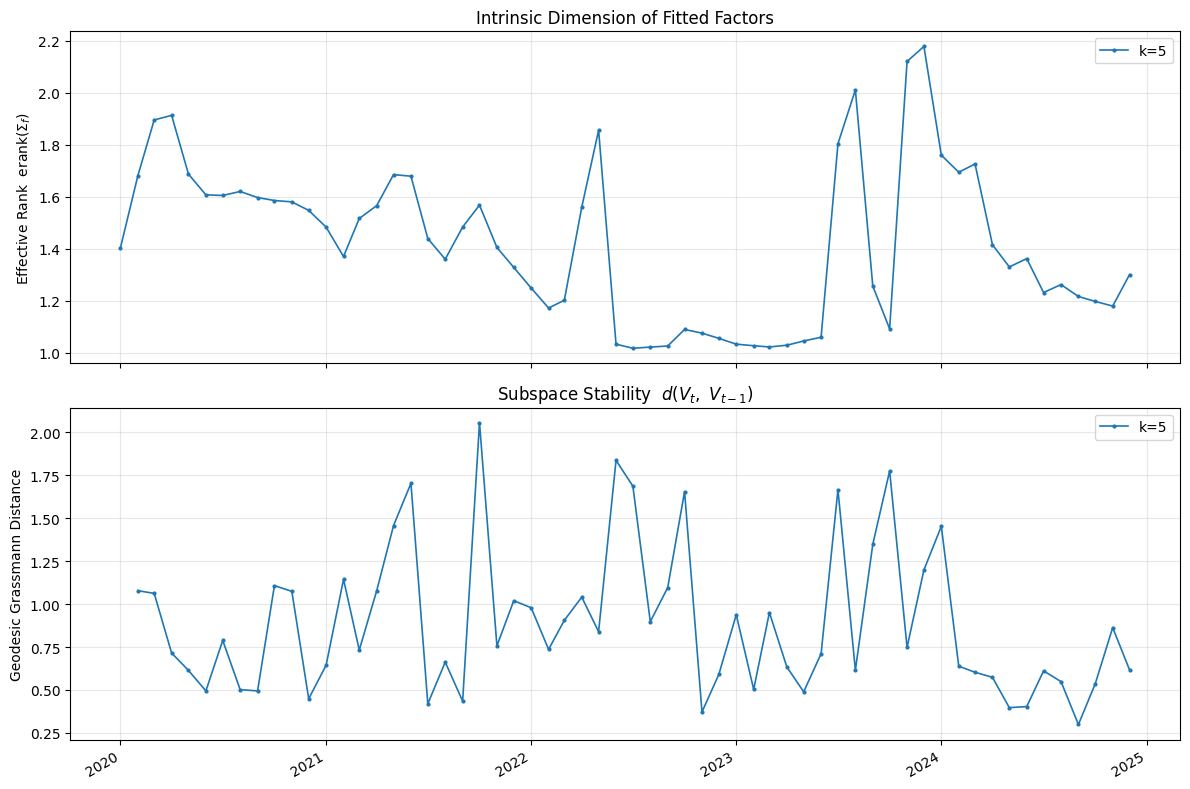

In [39]:
diag_dfs = {"k=5": diag_df_in}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for label, df in diag_dfs.items():
    t = pd.to_datetime(df["yyyymm"])
    axes[0].plot(t, df["erank"], marker="o", markersize=2, linewidth=1.2, label=label)
    axes[1].plot(t, df["grassmann_dist"], marker="o", markersize=2, linewidth=1.2, label=label)

axes[0].set_ylabel("Effective Rank  erank($\\Sigma_f$)")
axes[0].set_title("Intrinsic Dimension of Fitted Factors")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("Geodesic Grassmann Distance")
axes[1].set_title("Subspace Stability  $d(V_t,\\ V_{t-1})$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [40]:
diag_df_in.mean()

yyyymm            2022-06-16 15:12:00
erank                        1.421367
grassmann_dist               0.885374
n_train                   1551.383333
n_test                      44.816667
dtype: object

In [3]:
import sys, importlib
from pathlib import Path

ROOT = Path("/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Clear cached mixed imports
for name in list(sys.modules):
    if name == "ipca" or name.startswith("ipca."):
        del sys.modules[name]

import ipca
import ipca.ipca as ipca_mod

print("ipca package:", ipca.__file__)
print("ipca module :", ipca_mod.__file__)

from ipca import InstrumentedPCA


ipca package: /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/__init__.py
ipca module : /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/ipca.py


In [11]:
char_data["permno"] = pd.to_numeric(char_data["permno"], errors="coerce")
returns_data["permno"] = pd.to_numeric(returns_data["permno"], errors="coerce")

# Top 50 by median market cap (uses CRSP prc * shrout)
top50_permnos = (
    returns_data
    .assign(mcap=lambda d: d["prc"].abs() * d["shrout"])
    .dropna(subset=["permno", "mcap"])
    .groupby("permno")["mcap"]
    .median()
    .nlargest(50)
    .index
)

# Filter panel to those 50 stocks
char_data_50 = (
    char_data[char_data["permno"].isin(top50_permnos)]
    .sort_values(["yyyymm", "permno"])
    .reset_index(drop=True)
)

print("Stocks kept:", char_data_50["permno"].nunique(), "Rows:", len(char_data_50))

Stocks kept: 50 Rows: 13205


In [68]:
char_data.head()

,permno,yyyymm,AM,AnnouncementReturn,AssetGrowth,BMdec,Beta,BetaFP,BetaLiquidityPS,BidAskSpread,...,Spinoff,Tax,VolSD,VolumeTrend,betaVIX,hire,Price,Size,STreversal,excess_ret
0,10104,1990-01-01,0.165410,-0.098054,-0.844022,0.200682,1.629251,2.005819,-0.560545,0.013333,...,0.0,1.183506,-6.923829,-0.053363,-0.003889,-0.610858,-3.068053,-7.931008,0.080214,-0.080214
1,11308,1990-01-01,0.316938,-0.005730,0.108305,0.207617,0.763298,1.477842,0.064298,0.006482,...,0.0,1.349075,-4.141400,-0.007244,-0.000563,-0.075966,-4.232293,-10.065099,0.108414,-0.108414
2,11850,1990-01-01,1.262913,-0.017089,-0.003390,0.757861,0.550150,0.996026,0.064907,0.008670,...,0.0,1.608141,-7.058310,-0.010419,0.003740,-0.009950,-3.850147,-10.982351,0.060000,-0.06
3,12060,1990-01-01,1.973820,-0.007012,-1.848535,0.540474,0.909237,1.458372,0.162037,0.004840,...,0.0,1.110976,-8.619508,-0.016503,0.001266,0.013333,-4.131158,-10.936098,0.034884,-0.034884
4,12490,1990-01-01,1.279358,0.022973,-0.146794,0.611539,0.713131,1.065114,0.049926,0.005629,...,0.0,1.950250,-9.024756,-0.003066,0.000569,0.005759,-4.591325,-10.952363,-0.047809,0.047809


In [98]:
import importlib
import src.ipca_workflow as ipw
importlib.reload(ipw)
import ipca as ipca
importlib.reload(ipca)
wf = ipw.IPCAWorkflow()
k = 5
pred_df_in, diag_df_in = wf.rolling_ipca_predictions(
    char_data=char_data,
    forecast_start="2020-01-01",
    target_col="y_ipca",
    n_factors=k,              # use k here
    train_window_months=36,
    min_train_obs=500,
    normalize=True,
    mean_factor=True,
    silent=True,
    max_iter=200,
    iter_tol=1e-5,
    warm_start=True,
    use_rff=False,
    alpha=0.01,
)


Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=auto, warm_Gamma=False, warm_Factors=False
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=auto, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=auto, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=auto, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=auto, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=auto, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol

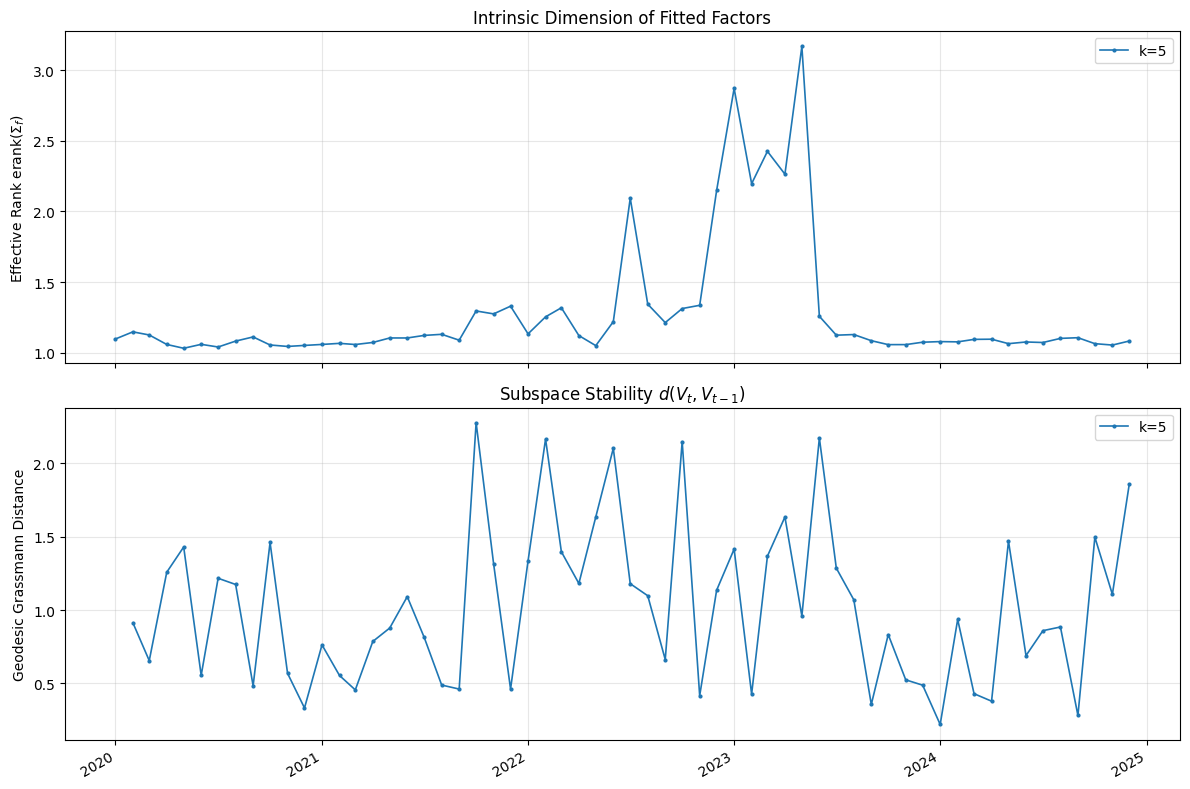

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

diag_dfs = {"k=5": diag_df_in}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for label, df in diag_dfs.items():
    d = df.copy()

    # robust date parsing + sort
    d["yyyymm"] = pd.to_datetime(d["yyyymm"], errors="coerce")
    d = d.dropna(subset=["yyyymm"]).sort_values("yyyymm")

    # robust numeric parsing
    d["erank"] = pd.to_numeric(d["erank"], errors="coerce")
    d["grassmann_dist"] = pd.to_numeric(d["grassmann_dist"], errors="coerce")

    axes[0].plot(d["yyyymm"], d["erank"], marker="o", markersize=2, linewidth=1.2, label=label)
    axes[1].plot(d["yyyymm"], d["grassmann_dist"], marker="o", markersize=2, linewidth=1.2, label=label)

axes[0].set_ylabel(r"Effective Rank $\mathrm{erank}(\Sigma_f)$")
axes[0].set_title("Intrinsic Dimension of Fitted Factors")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("Geodesic Grassmann Distance")
axes[1].set_title(r"Subspace Stability $d(V_t, V_{t-1})$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [109]:
import os
import time
import pickle
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

import importlib
import src.ipca_workflow as ipw
importlib.reload(ipw)
importlib.reload(ipca)

k = 5
results = {}

def run_one_seed(seed: int, rff_n_components: int = 1000) -> Tuple[int, pd.DataFrame, pd.DataFrame, float]:
    wf = ipw.IPCAWorkflow()
    t0 = time.time()

    pred_df_in, diag_df_in = wf.rolling_ipca_predictions(
        char_data=char_data,
        forecast_start="2020-01-01",
        target_col="y_ipca",
        n_factors=k,
        train_window_months=36,
        min_train_obs=500,
        normalize=True,
        mean_factor=True,
        silent=True,
        max_iter=200,
        iter_tol=1e-5,
        warm_start=True,
        use_rff=True,
        rff_n_components=rff_n_components,
        rff_gamma=0.25,
        rff_random_state=seed,   # <- different seed = different RFF draw
        ridge_solver="cholesky", # more stable for large n_components, can switch to "auto" or "sparse_cg" if preferred
        alpha=0.01,
    )
    return seed, pred_df_in, diag_df_in, time.time() - t0

rff_components = [500, 1000, 2000, 3000]
done = 0
seed = 42
for rff_n_components in rff_components:
    print(f"Running seed={seed} with rff_n_components={rff_n_components}...")
    seed, pred, diag, dt = run_one_seed(seed*4, rff_n_components=rff_n_components)
    results[rff_n_components] = {
        "pred": pred,
        "diag": diag,
        "secs": dt,
    }
    done += 1
    print(f"[{time.strftime('%H:%M:%S')}] completed {done}/{len(rff_components)} seed={seed}", flush=True)


Running seed=42 with rff_n_components=500...
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=cholesky, warm_Gamma=False, warm_Factors=False
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=cholesky, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=cholesky, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=cholesky, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=cholesky, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=200, iter_tol=1e-05, alpha=0.01, silent=True, ridge_solver=cholesky, warm_Gamma=True, warm_Factors=True

KeyboardInterrupt: 

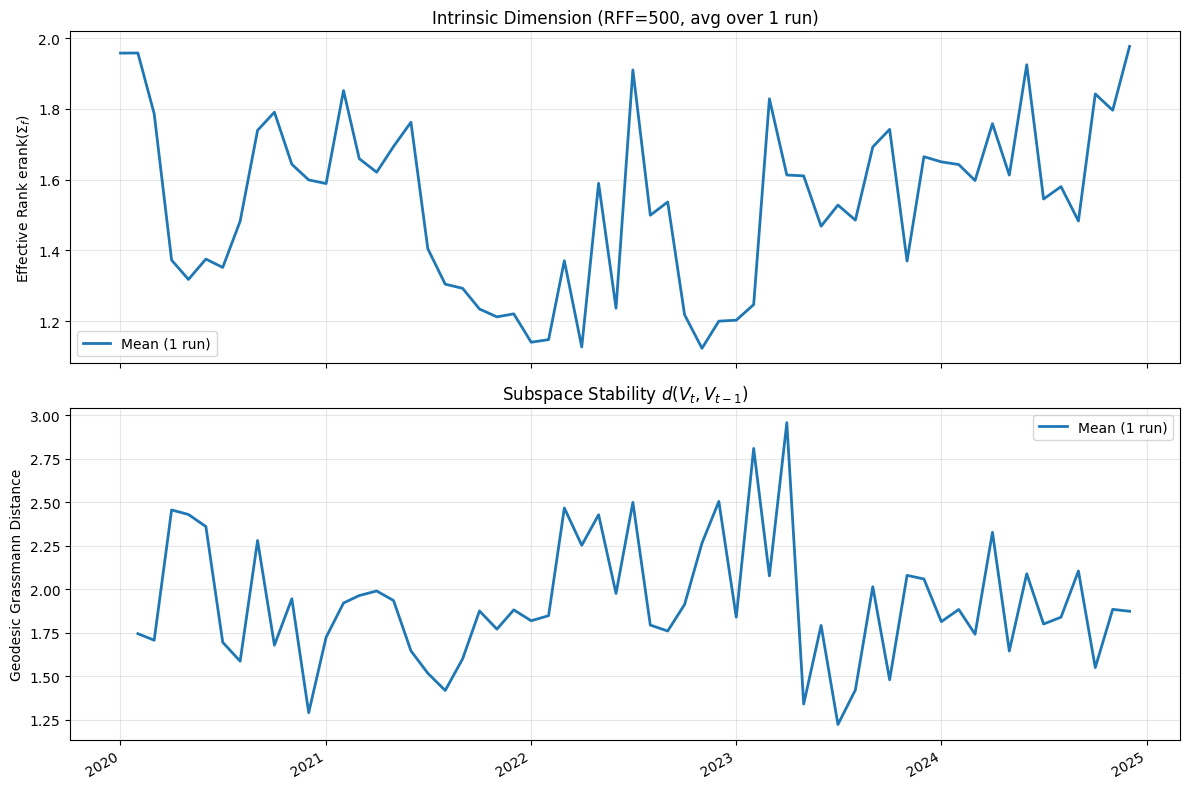

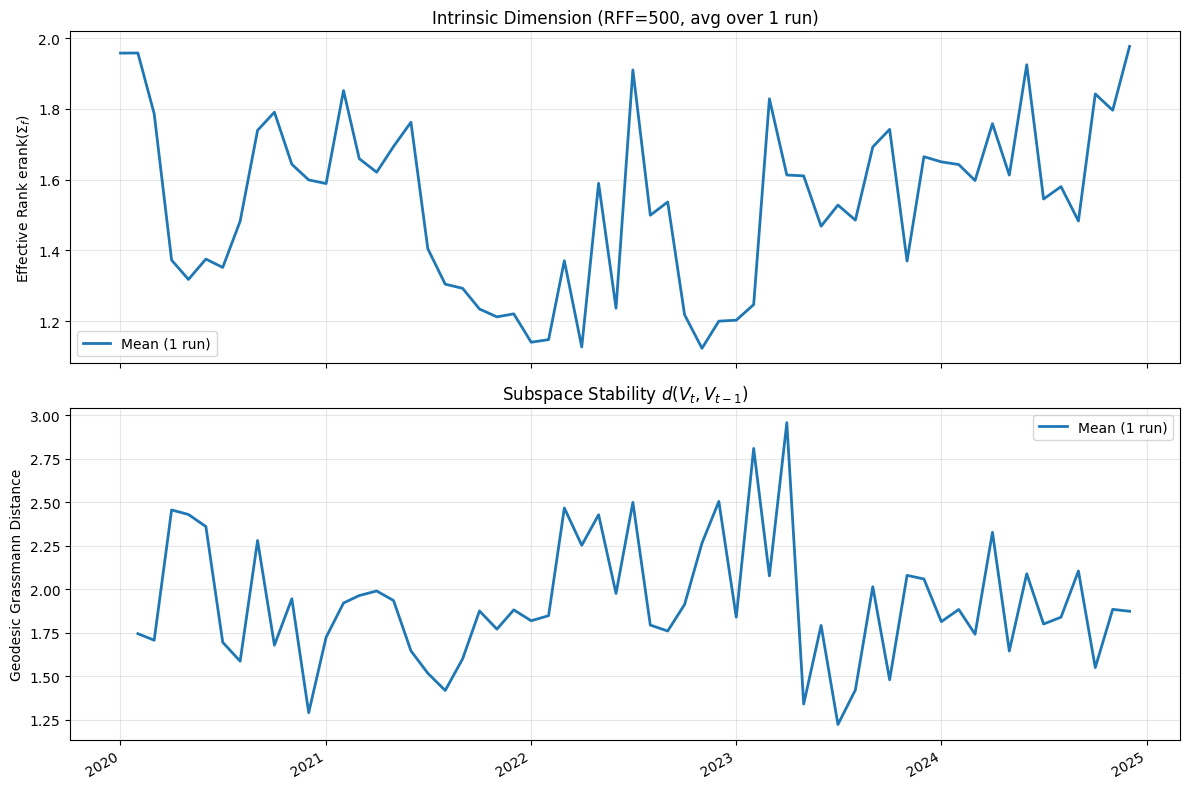

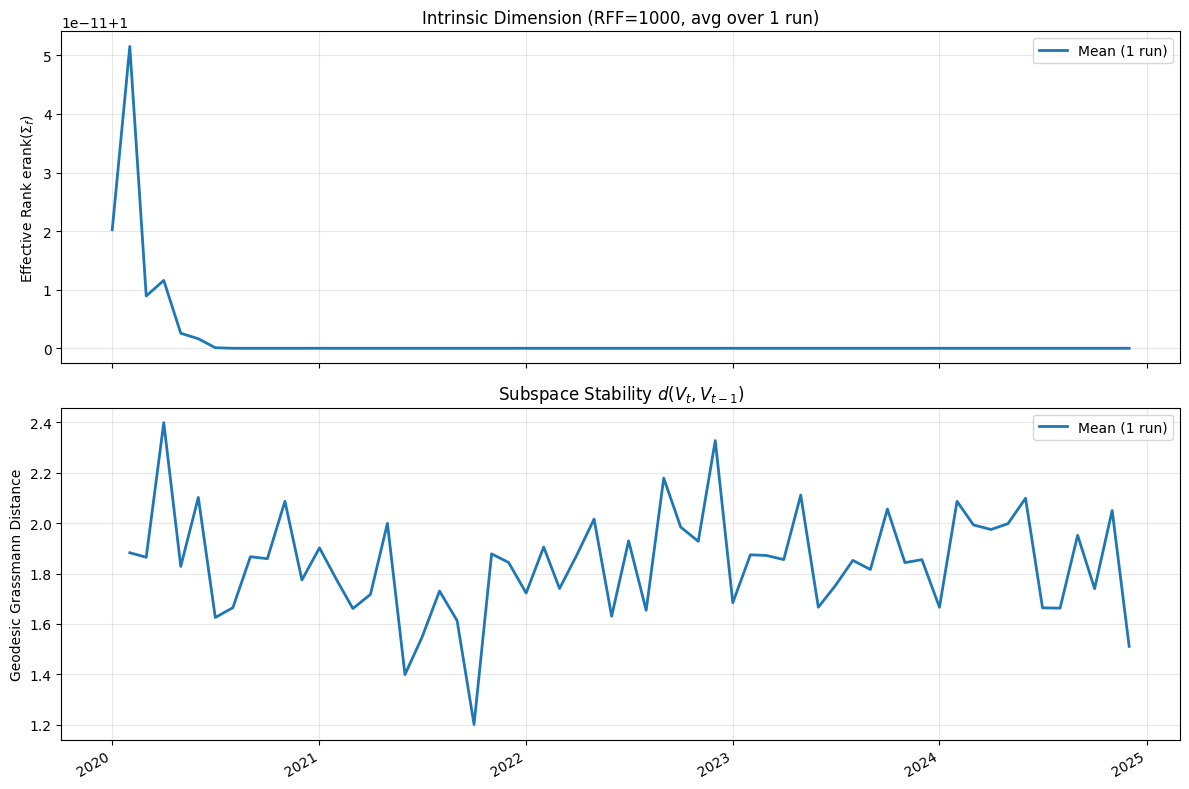

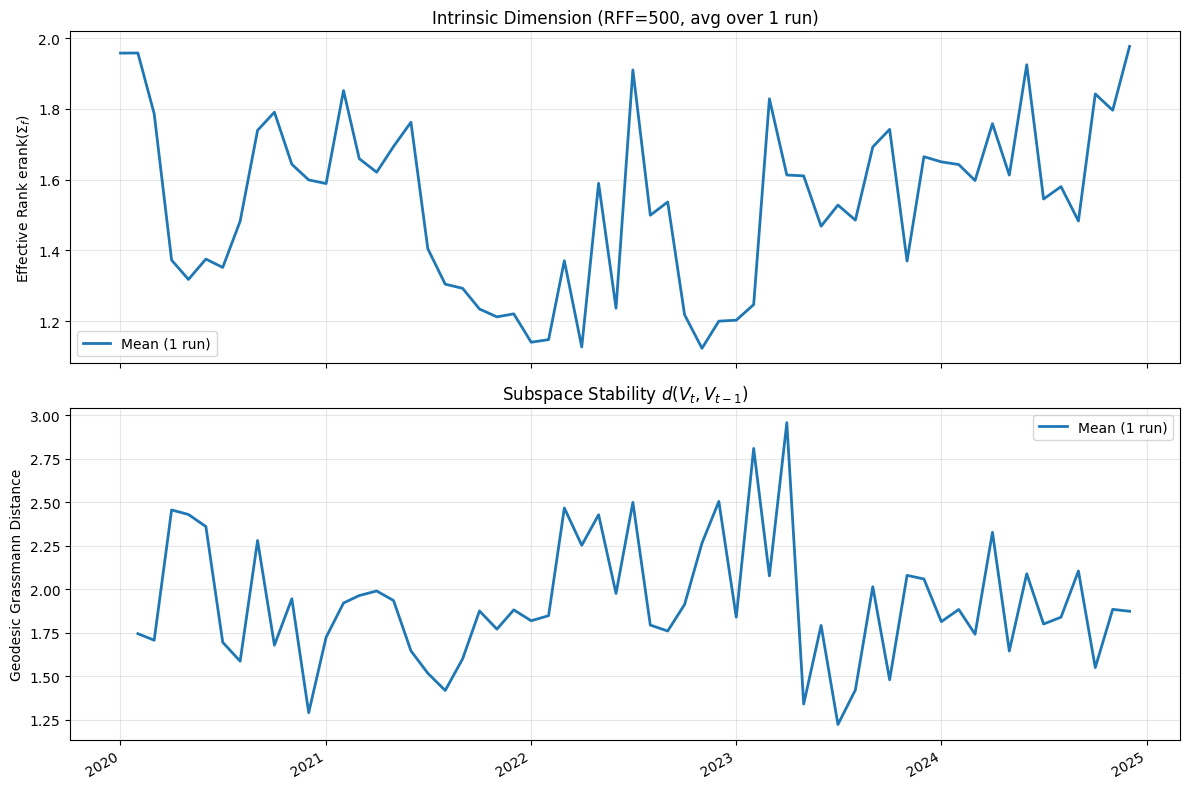

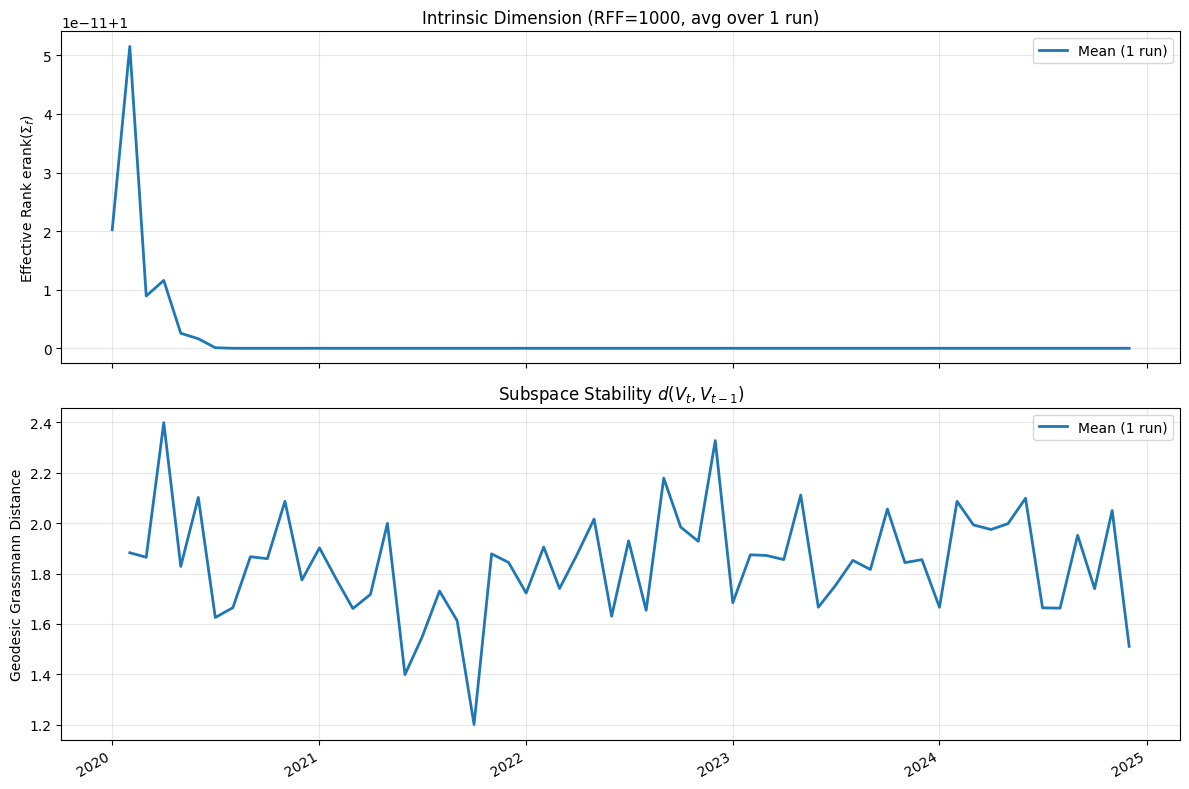

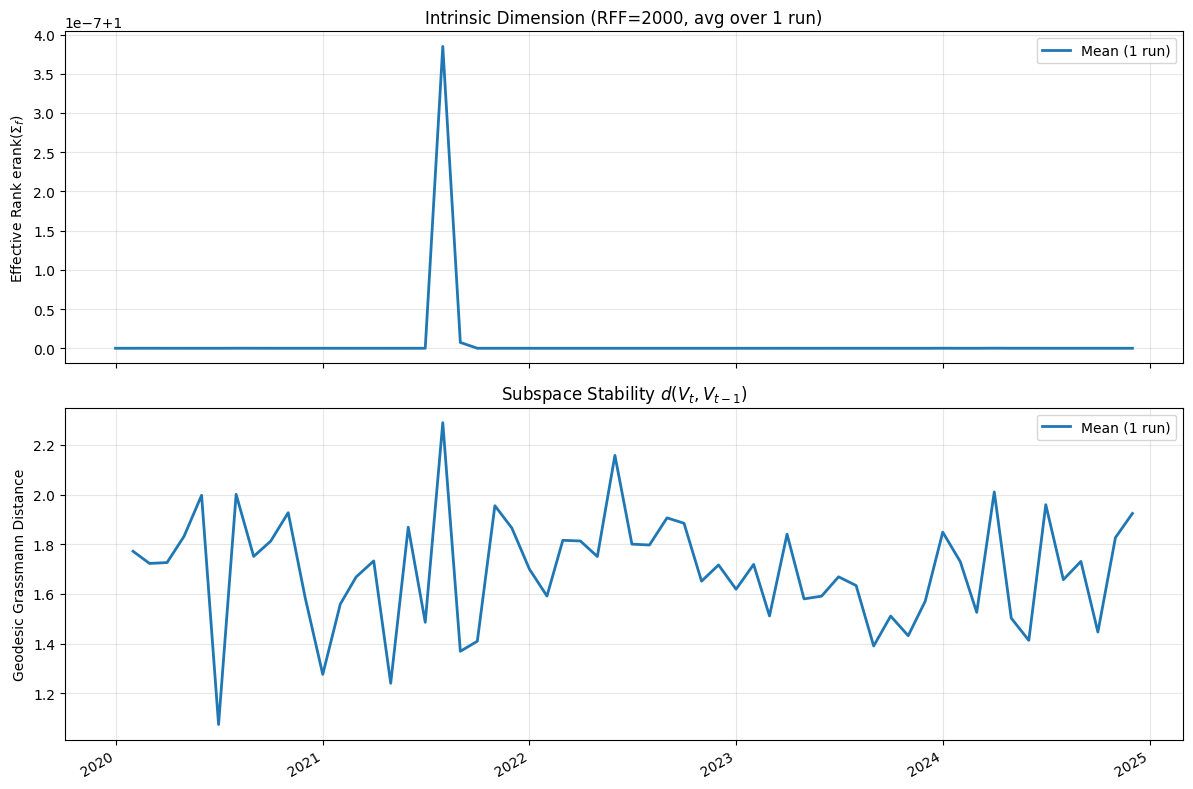

In [115]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Optional: set to a list like [20, 24, 28], or None for all seeds
selected_seeds = None

def _parse_rff_from_key(k):
    if isinstance(k, (int, float)) and pd.notna(k):
        return int(k)
    m = re.search(r"(\d+)", str(k))
    return int(m.group(1)) if m else None

def _infer_rff(run, fallback=None):
    if isinstance(run, dict):
        if "rff_n_components" in run and pd.notna(run["rff_n_components"]):
            return int(run["rff_n_components"])
        pred = run.get("pred")
        if isinstance(pred, pd.DataFrame) and "rff_n_components" in pred.columns:
            vals = pd.to_numeric(pred["rff_n_components"], errors="coerce").dropna()
            if not vals.empty:
                return int(vals.iloc[0])
    return fallback

# Flatten results into (seed, rff, diag_df)
records = []
for outer_k, outer_v in results.items():
    # Format A: results[seed] = {"pred":..., "diag":..., ...}
    if isinstance(outer_v, dict) and "diag" in outer_v:
        seed = outer_k
        if selected_seeds is None or seed in selected_seeds:
            rff = _infer_rff(outer_v, fallback=None)
            records.append((seed, rff, outer_v["diag"]))
        continue

    # Format B: results[rff][seed] = {"pred":..., "diag":..., ...}
    if isinstance(outer_v, dict):
        rff_from_key = _parse_rff_from_key(outer_k)
        for seed, run in outer_v.items():
            if not isinstance(run, dict) or "diag" not in run:
                continue
            if selected_seeds is not None and seed not in selected_seeds:
                continue
            rff = _infer_rff(run, fallback=rff_from_key)
            records.append((seed, rff, run["diag"]))

diag_stack = []
for seed, rff, d in records:
    if d is None or len(d) == 0:
        continue
    d = d.copy()
    d["yyyymm"] = pd.to_datetime(d["yyyymm"], errors="coerce")
    d["erank"] = pd.to_numeric(d["erank"], errors="coerce")
    d["grassmann_dist"] = pd.to_numeric(d["grassmann_dist"], errors="coerce")
    d = d.dropna(subset=["yyyymm"])
    d["seed"] = seed
    d["rff_n_components"] = rff
    diag_stack.append(d[["yyyymm", "erank", "grassmann_dist", "seed", "rff_n_components"]])

if not diag_stack:
    raise ValueError("No diagnostic data found in `results` for the chosen seeds.")

diag_all = pd.concat(diag_stack, ignore_index=True)

if diag_all["rff_n_components"].isna().all():
    diag_all["rff_n_components"] = "unknown"
else:
    diag_all["rff_n_components"] = diag_all["rff_n_components"].fillna("unknown")

rff_values = sorted(diag_all["rff_n_components"].unique(), key=lambda x: (isinstance(x, str), x))

for rff in rff_values:
    dsub = diag_all[diag_all["rff_n_components"] == rff].copy()

    diag_avg = (
        dsub.groupby("yyyymm", as_index=False)
        .agg(
            erank_mean=("erank", "mean"),
            gdist_mean=("grassmann_dist", "mean"),
            erank_std=("erank", "std"),
            gdist_std=("grassmann_dist", "std"),
        )
        .sort_values("yyyymm")
    )

    n_runs = int(dsub["seed"].nunique())
    label = f"Mean ({n_runs} run{'s' if n_runs != 1 else ''})"

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(diag_avg["yyyymm"], diag_avg["erank_mean"], linewidth=2, label=label)
    axes[1].plot(diag_avg["yyyymm"], diag_avg["gdist_mean"], linewidth=2, label=label)

    if n_runs > 1:
        axes[0].fill_between(
            diag_avg["yyyymm"],
            diag_avg["erank_mean"] - diag_avg["erank_std"].fillna(0),
            diag_avg["erank_mean"] + diag_avg["erank_std"].fillna(0),
            alpha=0.2,
        )
        axes[1].fill_between(
            diag_avg["yyyymm"],
            diag_avg["gdist_mean"] - diag_avg["gdist_std"].fillna(0),
            diag_avg["gdist_mean"] + diag_avg["gdist_std"].fillna(0),
            alpha=0.2,
        )

    axes[0].set_ylabel(r"Effective Rank $\mathrm{erank}(\Sigma_f)$")
    axes[0].set_title(f"Intrinsic Dimension (RFF={rff}, avg over {n_runs} run{'s' if n_runs != 1 else ''})")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].set_ylabel("Geodesic Grassmann Distance")
    axes[1].set_title(r"Subspace Stability $d(V_t, V_{t-1})$")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator(1))

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


In [103]:

selected_seeds = sorted(results)# pick the 4 runs you want

pred_stack = []
for s in selected_seeds:
    d = results[s]["pred"].copy()  # if tuple-style, use: results[s][0]
    d["permno"] = pd.to_numeric(d["permno"], errors="coerce")
    d["yyyymm"] = pd.to_datetime(d["yyyymm"], errors="coerce")
    d["y_pred"] = pd.to_numeric(d["y_pred"], errors="coerce")
    d["y_true"] = pd.to_numeric(d["y_true"], errors="coerce")
    d["seed"] = s
    pred_stack.append(d[["permno", "yyyymm", "y_pred", "y_true", "seed"]])

pred_all = pd.concat(pred_stack, ignore_index=True).dropna(subset=["permno", "yyyymm", "y_pred"])

pred_avg_df = (
    pred_all
    .groupby(["permno", "yyyymm"], as_index=False)
    .agg(
        y_pred_avg=("y_pred", "mean"),
        y_pred_std=("y_pred", "std"),
        y_true=("y_true", "first"),
        n_runs=("seed", "nunique"),
    )
    .sort_values(["yyyymm", "permno"])
    .reset_index(drop=True)
)

pred_avg_df.head()

,permno,yyyymm,y_pred_avg,y_pred_std,y_true,n_runs
0,10104,2020-01-01,-0.019859,NaN,-0.057007,1
1,10107,2020-01-01,-0.021577,NaN,-0.045292,1
2,11308,2020-01-01,0.013270,NaN,-0.084075,1
3,11850,2020-01-01,-0.020486,NaN,-0.157920,1
4,12060,2020-01-01,0.007327,NaN,-0.126104,1


In [125]:
performance = {}
from src.portfolio_utils import (
    build_long_only_portfolio,
    compute_portfolio_returns,
    portfolio_performance,
    plot_cumulative,
)
for key, result in results.items():
    pred_df = result["pred"]
    pred_df.rename(columns={"actual_return": "y_true", "expected_return": "y_pred"}, inplace=True)
    port = build_long_only_portfolio(
        pred_df=pred_df,
        top_n=100,      # change as needed
        threshold=0.0001,  # keep only positive expected return
    )

    monthly = compute_portfolio_returns(port)
    stats = portfolio_performance(monthly)
    performance[key] = stats
print(performance)

Annualized Return : 17.06%
Annualized Vol    : 17.55%
Sharpe Ratio      : 0.97
Max Drawdown      : -22.39%
Hit Rate          : 66.10%
Annualized Return : 17.59%
Annualized Vol    : 19.22%
Sharpe Ratio      : 0.92
Max Drawdown      : -25.17%
Hit Rate          : 64.41%
Annualized Return : 18.88%
Annualized Vol    : 19.52%
Sharpe Ratio      : 0.97
Max Drawdown      : -23.14%
Hit Rate          : 69.49%
{500: {'ann_ret': 0.17056750505570162, 'ann_vol': 0.1755214432271632, 'sharpe': 0.971775880596822, 'max_dd': -0.223866705188759, 'hit_rate': 0.6610169491525424}, 1000: {'ann_ret': 0.17592347784225834, 'ann_vol': 0.19223116041369293, 'sharpe': 0.9151662897090176, 'max_dd': -0.2517326064921551, 'hit_rate': 0.6440677966101694}, 2000: {'ann_ret': 0.18876651497405367, 'ann_vol': 0.19522598117174292, 'sharpe': 0.9669128762528448, 'max_dd': -0.23137405646997788, 'hit_rate': 0.6949152542372882}}


In [ ]:
import pandas as pd

def direction_counts(pred_df, date_col="yyyymm", y_true_col="y_true", y_pred_col="y_pred"):
    d = pred_df[[date_col, y_true_col, y_pred_col]].copy()
    d[date_col] = pd.to_datetime(d[date_col], errors="coerce")
    d[y_true_col] = pd.to_numeric(d[y_true_col], errors="coerce")
    d[y_pred_col] = pd.to_numeric(d[y_pred_col], errors="coerce")
    d = d.dropna()

    d["true_up"] = d[y_true_col] > 0
    d["pred_up"] = d[y_pred_col] > 0
    d["correct"] = d["true_up"] == d["pred_up"]

    overall = pd.Series({
        "n_obs": len(d),
        "n_correct": int(d["correct"].sum()),
        "accuracy": float(d["correct"].mean()),
        "tp": int((d["pred_up"] & d["true_up"]).sum()),
        "tn": int((~d["pred_up"] & ~d["true_up"]).sum()),
        "fp": int((d["pred_up"] & ~d["true_up"]).sum()),
        "fn": int((~d["pred_up"] & d["true_up"]).sum()),
    })

    by_month = (
        d.groupby(d[date_col].dt.to_period("M").dt.to_timestamp(), as_index=False)
         .agg(
             n_obs=("correct", "size"),
             n_correct=("correct", "sum"),
             accuracy=("correct", "mean"),
             tp=("pred_up", lambda s: int((s & d.loc[s.index, "true_up"]).sum())),
             tn=("pred_up", lambda s: int((~s & ~d.loc[s.index, "true_up"]).sum())),
             fp=("pred_up", lambda s: int((s & ~d.loc[s.index, "true_up"]).sum())),
             fn=("pred_up", lambda s: int((~s & d.loc[s.index, "true_up"]).sum())),
         )
         .rename(columns={date_col: "yyyymm"})
    )
    return overall, by_month
for key, result in results.items():
    pred_df = result["pred"]
    pred_df.rename(columns={"actual_return": "y_true", "expected_return": "y_pred"}, inplace=True)
    overall, by_month = direction_counts(pred_df)
    print(f"RFFS {key} - Overall Accuracy: {overall['accuracy']:.4f}")

/var/folders/nf/zfnfl40j2hb_zjsqj1rbjq140000gn/T/ipykernel_15669/1504297235.py:26: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(
/var/folders/nf/zfnfl40j2hb_zjsqj1rbjq140000gn/T/ipykernel_15669/1504297235.py:26: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(
/var/folders/nf/zfnfl40j2hb_zjsqj1rbjq140000gn/T/ipykernel_15669/1504297235.py:26: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence th

RFFS 500 - Overall Accuracy: 0.5028
   n_obs  n_correct  accuracy  tp  tn  fp  fn
0     43         19  0.441860   2  17  23   1
1     43         10  0.232558   3   7  32   1
2     43         12  0.279070  12   0   1  30
3     43         25  0.581395  18   7   6  12
4     43         21  0.488372   8  13  10  12
RFFS 1000 - Overall Accuracy: 0.4847
   n_obs  n_correct  accuracy  tp  tn  fp  fn
0     43         17  0.395349   2  15  25   1
1     43          7  0.162791   2   5  34   2
2     43         20  0.465116  20   0   1  22
3     43         21  0.488372  15   6   7  15
4     43         20  0.465116  11   9  14   9
RFFS 2000 - Overall Accuracy: 0.4862
   n_obs  n_correct  accuracy  tp  tn  fp  fn
0     43         19  0.441860   1  18  22   2
1     43         10  0.232558   1   9  30   3
2     43         26  0.604651  26   0   1  16
3     43         33  0.767442  27   6   7   3
4     43         20  0.465116  11   9  14   9


yyyymm            2022-06-16 15:12:00
erank                        4.035074
grassmann_dist               1.300031
seed                            320.0
dtype: object

dict_keys([168, 672, 2688])

Old keys: [168, 672, 2688]
New keys: [500, 1000, 2000]


In [114]:
results = results_by_components